In [17]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from pathlib import Path
import sys

import pandas as pd


import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from pathlib import Path
import sys
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import optuna
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer



from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

sys.path.append(str(Path().resolve().parent))
import src.data_processing.data_processing as dp
import src.data_processing.building_dataset as bd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


sys.path.append(str(Path().resolve().parent))
import src.data_processing.data_processing as dp
import src.data_processing.building_dataset as bd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_status = pd.read_csv("../data/processed/status.csv")
dp.str_to_int_student_status(df_status)
df_encoding = bd.encoding(df_status, 'onehot', target='student_status')
X = df_encoding.drop(columns=['student_id_hash', 'student_status'])
y = df_encoding['student_status']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

target_majority_size = 40000  

under_sampler = RandomUnderSampler(
    sampling_strategy={0: target_majority_size}, 
    random_state=42
)

over_sampler = SMOTE(
    sampling_strategy='minority', 
    random_state=42
)

balancing_pipeline = Pipeline([
    ('under', under_sampler),
    ('over', over_sampler)
])

X_train_res, y_train_res = balancing_pipeline.fit_resample(X_train, y_train)


Лучший порог: 0.6695979899497487
Лучший F1: 0.8507718696397941
accuracy:  0.9907838983050847
recall:  0.797427652733119
precision:  0.9117647058823529
[[9105   24]
 [  63  248]]


/tmp/ipykernel_41568/777755368.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


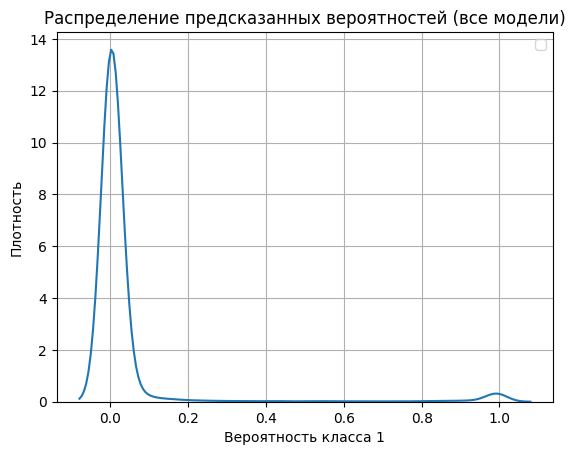

,Accuracy,Precision,Precision_w,Recall,Recall_w,F1-Score,F1-Score_w
0,0.9908,0.9118,0.9904,0.7974,0.9908,0.8508,0.9905


In [ ]:


neg = (y_train_res == 0).sum()
pos = (y_train_res == 1).sum()

scale_pos_weight = neg / pos


model = XGBClassifier( random_state=42)
model.fit(X_train_res, y_train_res)
y_proba = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.05, 0.95, 200)

best_threshold = 0.5
best_f1 = 0
accuracy = 0


for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        results = pd.DataFrame([{
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Precision_w': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred),
            'Recall_w': recall_score(y_test, y_pred, average='weighted'),
            'F1-Score': f1_score(y_test, y_pred),
            'F1-Score_w': f1_score(y_test, y_pred, average='weighted')}])
       
print("Лучший порог:", best_threshold)
print("Лучший F1:", best_f1)
print("accuracy: ", accuracy )
print('recall: ', recall)
print('precision: ', precision )
y_final = (y_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_final)
print(cm)

sns.kdeplot(y_proba, fill=False)

plt.title("Распределение предсказанных вероятностей (все модели)")
plt.xlabel("Вероятность класса 1")
plt.ylabel("Плотность")
plt.legend()
plt.grid()
plt.show()
results.round(4)


Лучший порог для высокого Recall: 0.4446
Recall на тесте: 0.8491
Precision на тесте: 0.8612
F1-Score на тесте: 0.8551


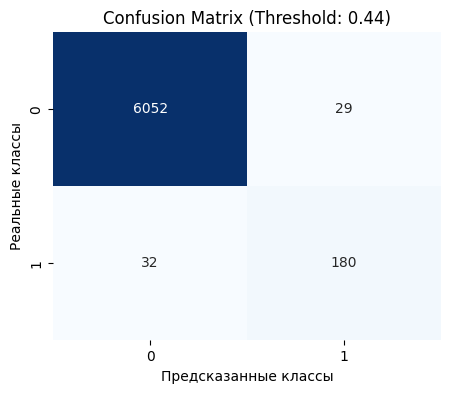

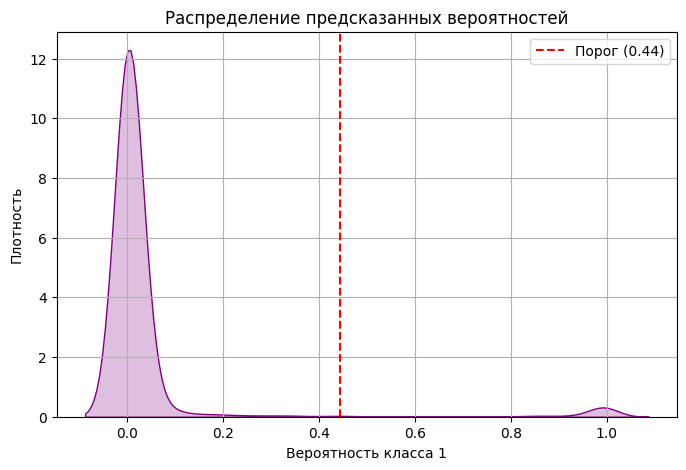

,Accuracy,Precision,Recall,F1-Score,Precision_w,Recall_w,F1-Score_w
0,0.9903,0.8612,0.8491,0.8551,0.9902,0.9903,0.9903


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, confusion_matrix

model = XGBClassifier( random_state=42)
model.fit(X_train_res, y_train_res)
y_proba = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.95, 200) 

best_threshold = 0.5
best_recall = 0
saved_metrics = {}

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    if rec > best_recall and prec > 0.85: 
        best_recall = rec
        best_threshold = t
        saved_metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'Precision_w': precision_score(y_test, y_pred, average='weighted'),
            'Recall_w': recall_score(y_test, y_pred, average='weighted'),
            'F1-Score_w': f1_score(y_test, y_pred, average='weighted')
        }

results = pd.DataFrame([saved_metrics])

print(f"Лучший порог для высокого Recall: {best_threshold:.4f}")
print(f"Recall на тесте: {saved_metrics['Recall']:.4f}")
print(f"Precision на тесте: {saved_metrics['Precision']:.4f}")
print(f"F1-Score на тесте: {saved_metrics['F1-Score']:.4f}")


y_final = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Threshold: {best_threshold:.2f})')
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(y_proba, fill=True, color="purple")
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Порог ({best_threshold:.2f})')
plt.title("Распределение предсказанных вероятностей")
plt.xlabel("Вероятность класса 1")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)
plt.show()

results.round(4)

/mnt/d/ml_project/ml_project_2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


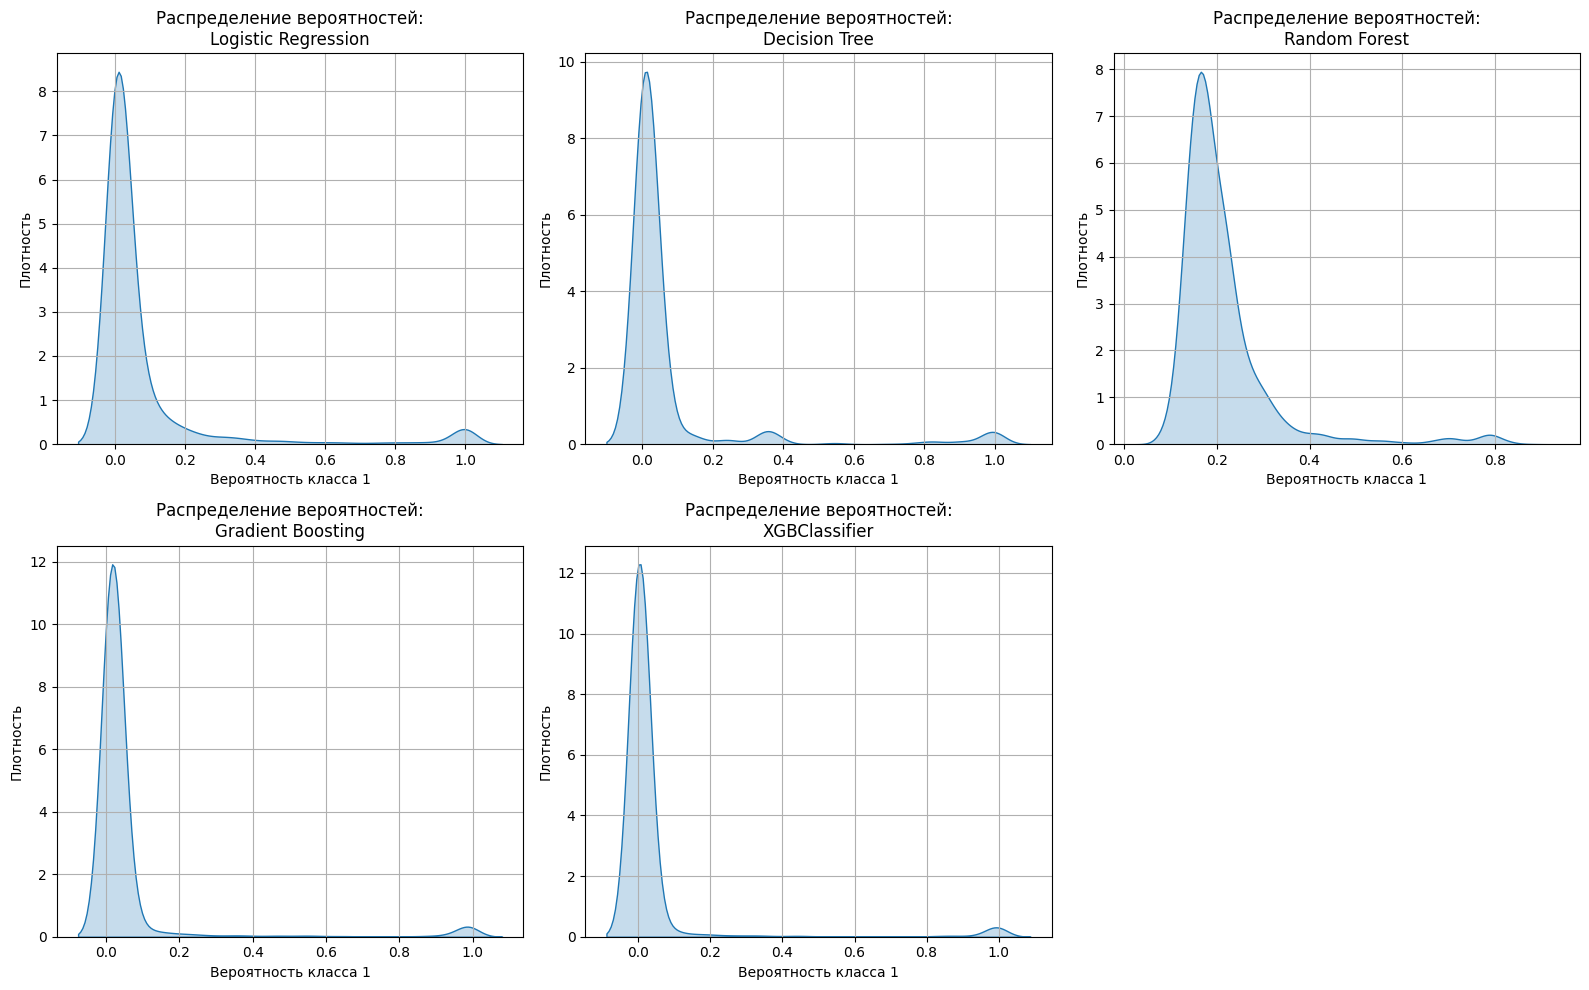


Результаты моделей с оптимизированными порогами:
              Model  Best_Threshold  Accuracy  Precision  Precision_w  Recall  Recall_w  F1-Score  F1-Score_w
Logistic Regression          0.9028    0.9897     0.8517       0.9896  0.8396    0.9897    0.8456      0.9896
      Decision Tree          0.9075    0.9895     0.9195       0.9891  0.7547    0.9895    0.8290      0.9890
      Random Forest          0.5249    0.9884     0.8564       0.9880  0.7877    0.9884    0.8206      0.9882
  Gradient Boosting          0.5674    0.9897     0.8517       0.9896  0.8396    0.9897    0.8456      0.9896
      XGBClassifier          0.4446    0.9903     0.8612       0.9902  0.8491    0.9903    0.8551      0.9903

Лучшая модель по F1-Score (с учетом оптимизации порога): XGBClassifier


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_split=4, min_samples_leaf=2, criterion='entropy', max_features=None, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=109, max_depth=16, min_samples_split=5, min_samples_leaf=1, max_features='log2', bootstrap=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=108, learning_rate=0.03736563332951993, max_depth=8, min_samples_split=13, min_samples_leaf=6, subsample=0.6816427025399264, max_features=None, random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42)
}

results = []
thresholds = np.linspace(0.01, 0.95, 200)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    
    
    model.fit(X_train_res, y_train_res)
    
  
    y_proba = model.predict_proba(X_test)[:, 1]
    
 
    best_t = 0.5
    best_recall = 0
    best_metrics = {}
    
    for t in thresholds:
        y_pred_temp = (y_proba >= t).astype(int)
        rec = recall_score(y_test, y_pred_temp, zero_division=0)
        prec = precision_score(y_test, y_pred_temp, zero_division=0)
        
        if rec > best_recall and prec > 0.85:
            best_recall = rec
            best_t = t
            best_metrics = {
                'Model': name,
                'Best_Threshold': round(t, 4),
                'Accuracy': accuracy_score(y_test, y_pred_temp),
                'Precision': prec,
                'Precision_w': precision_score(y_test, y_pred_temp, average='weighted', zero_division=0),
                'Recall': rec,
                'Recall_w': recall_score(y_test, y_pred_temp, average='weighted', zero_division=0),
                'F1-Score': f1_score(y_test, y_pred_temp, zero_division=0),
                'F1-Score_w': f1_score(y_test, y_pred_temp, average='weighted', zero_division=0)
            }
            
    if not best_metrics:
        y_pred_temp = (y_proba >= 0.5).astype(int)
        best_metrics = {
            'Model': name, 'Best_Threshold': 0.5,
            'Accuracy': accuracy_score(y_test, y_pred_temp), 'Precision': precision_score(y_test, y_pred_temp, zero_division=0),
            'Precision_w': precision_score(y_test, y_pred_temp, average='weighted', zero_division=0), 'Recall': recall_score(y_test, y_pred_temp, zero_division=0),
            'Recall_w': recall_score(y_test, y_pred_temp, average='weighted', zero_division=0), 'F1-Score': f1_score(y_test, y_pred_temp, zero_division=0),
            'F1-Score_w': f1_score(y_test, y_pred_temp, average='weighted', zero_division=0)
        }
        best_t = 0.5

    results.append(best_metrics)
    
    sns.kdeplot(y_proba, fill=True, ax=axes[i], label=name)
    axes[i].set_title(f"Распределение вероятностей:\n{name}")
    axes[i].set_xlabel("Вероятность класса 1")
    axes[i].set_ylabel("Плотность")
    axes[i].grid(True)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()
results_df = pd.DataFrame(results)
print("\nРезультаты моделей с оптимизированными порогами:")
print(results_df.round(4).to_string(index=False))

best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nЛучшая модель по F1-Score (с учетом оптимизации порога): {best_model}")

In [30]:
results_df.round(4)

,Model,Best_Threshold,Accuracy,Precision,Precision_w,Recall,Recall_w,F1-Score,F1-Score_w
0,Logistic Regression,0.9028,0.9897,0.8517,0.9896,0.8396,0.9897,0.8456,0.9896
1,Decision Tree,0.9075,0.9895,0.9195,0.9891,0.7547,0.9895,0.8290,0.9890
2,Random Forest,0.5249,0.9884,0.8564,0.9880,0.7877,0.9884,0.8206,0.9882
3,Gradient Boosting,0.5674,0.9897,0.8517,0.9896,0.8396,0.9897,0.8456,0.9896
4,XGBClassifier,0.4446,0.9903,0.8612,0.9902,0.8491,0.9903,0.8551,0.9903


/mnt/d/ml_project/ml_project_2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


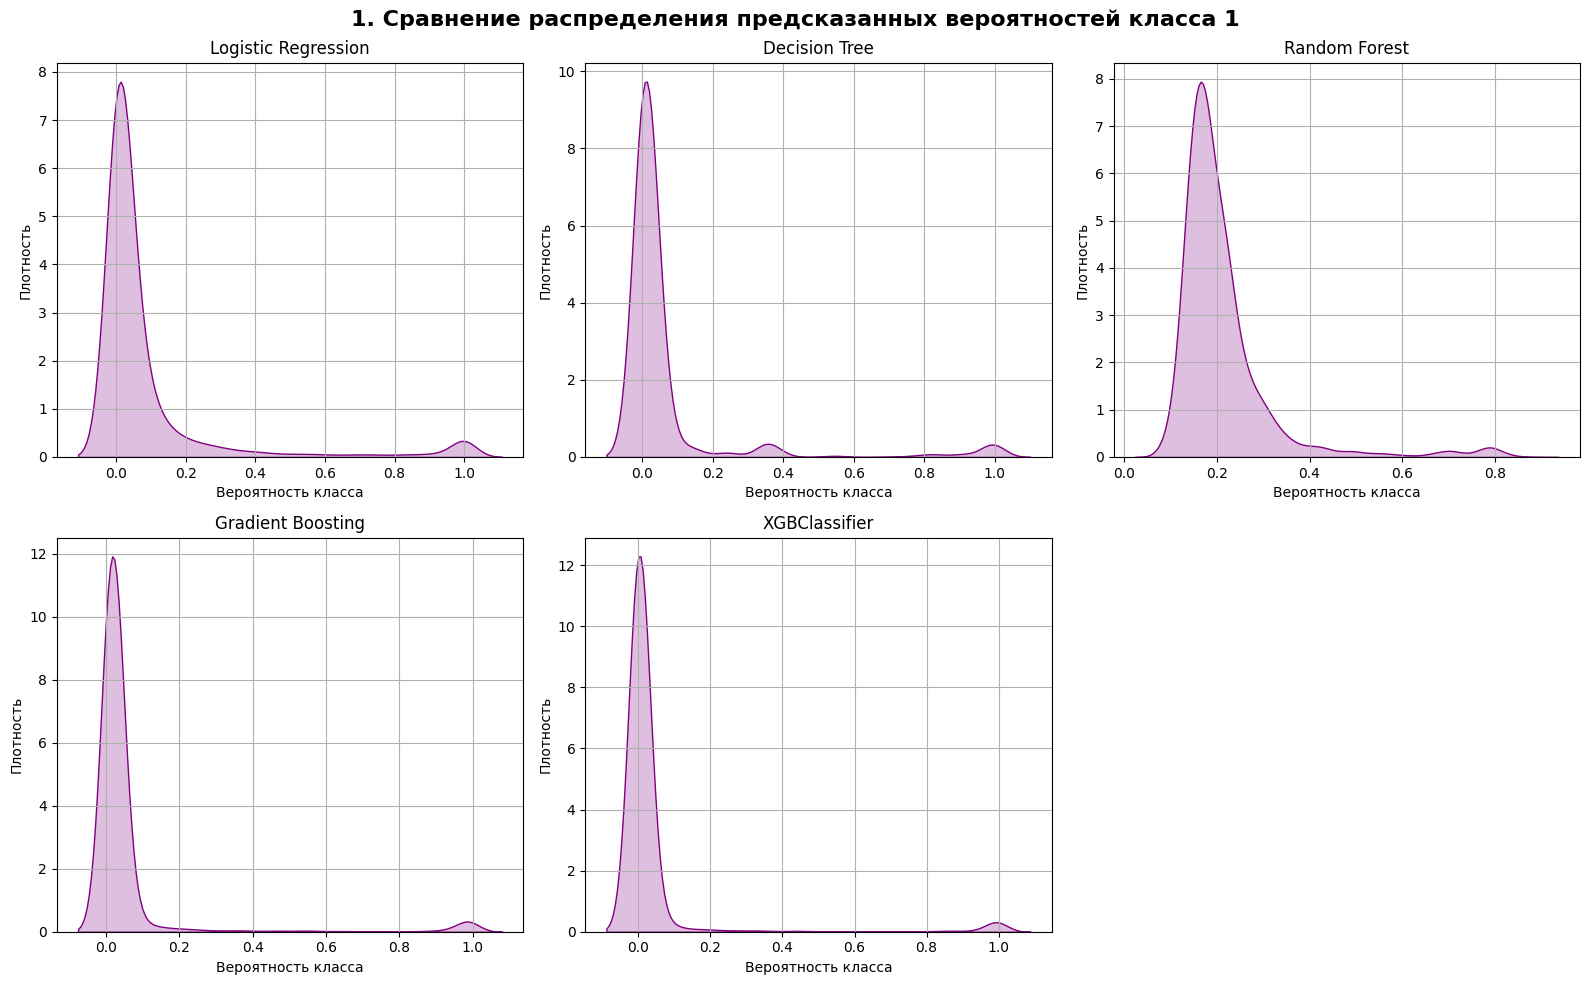

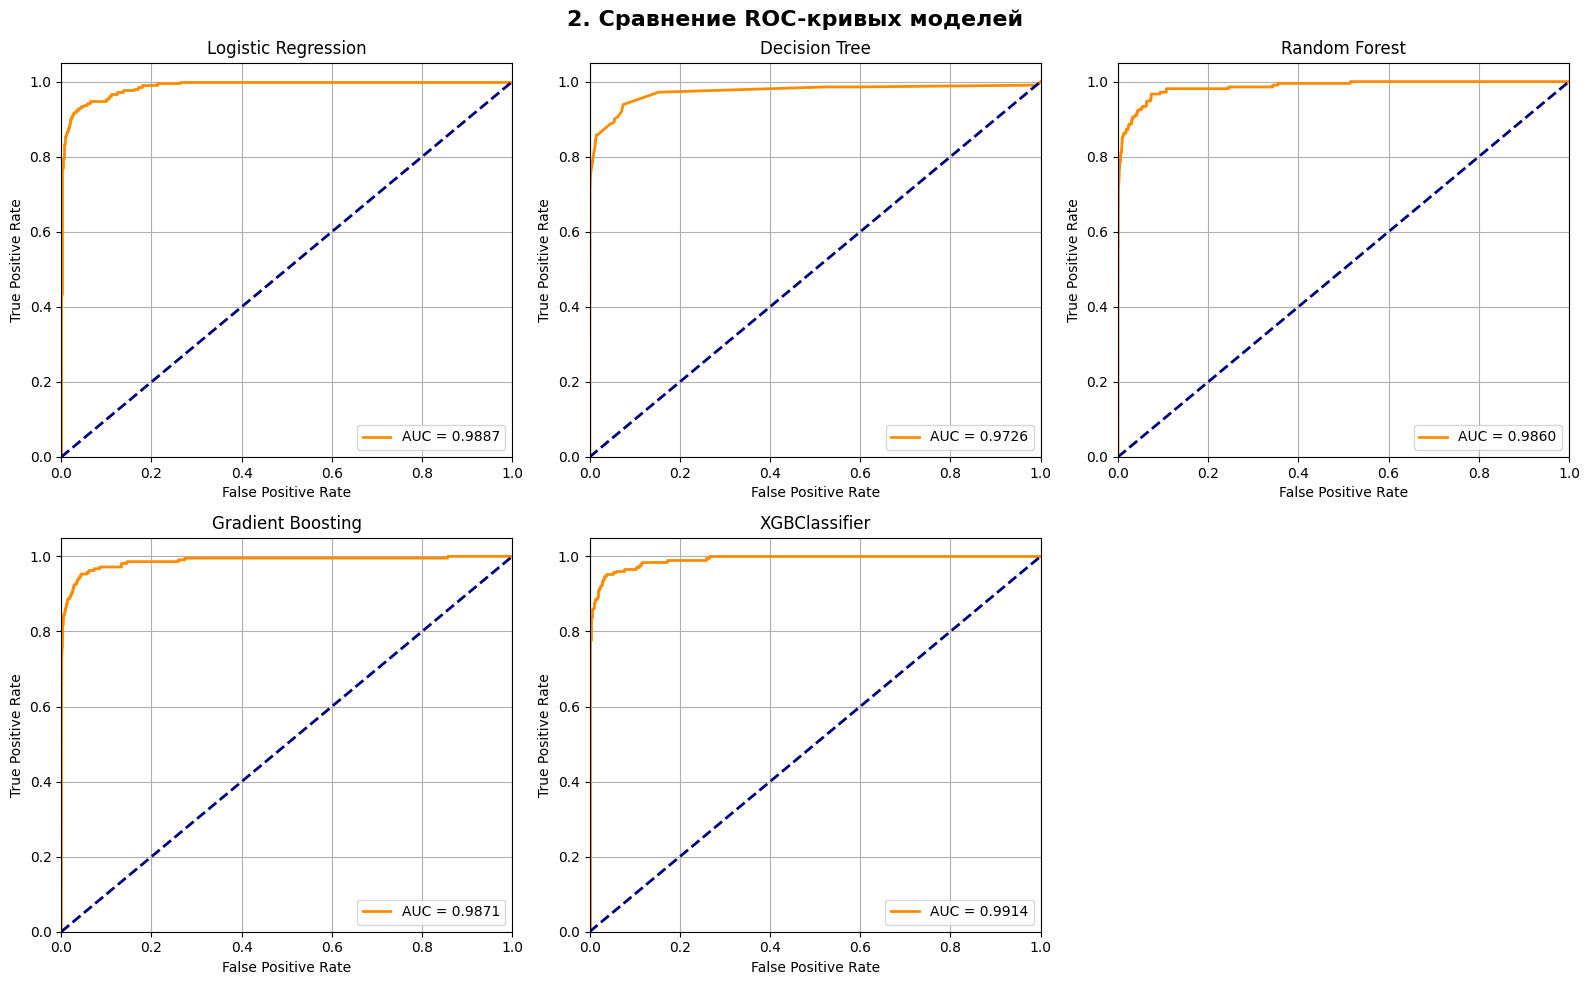

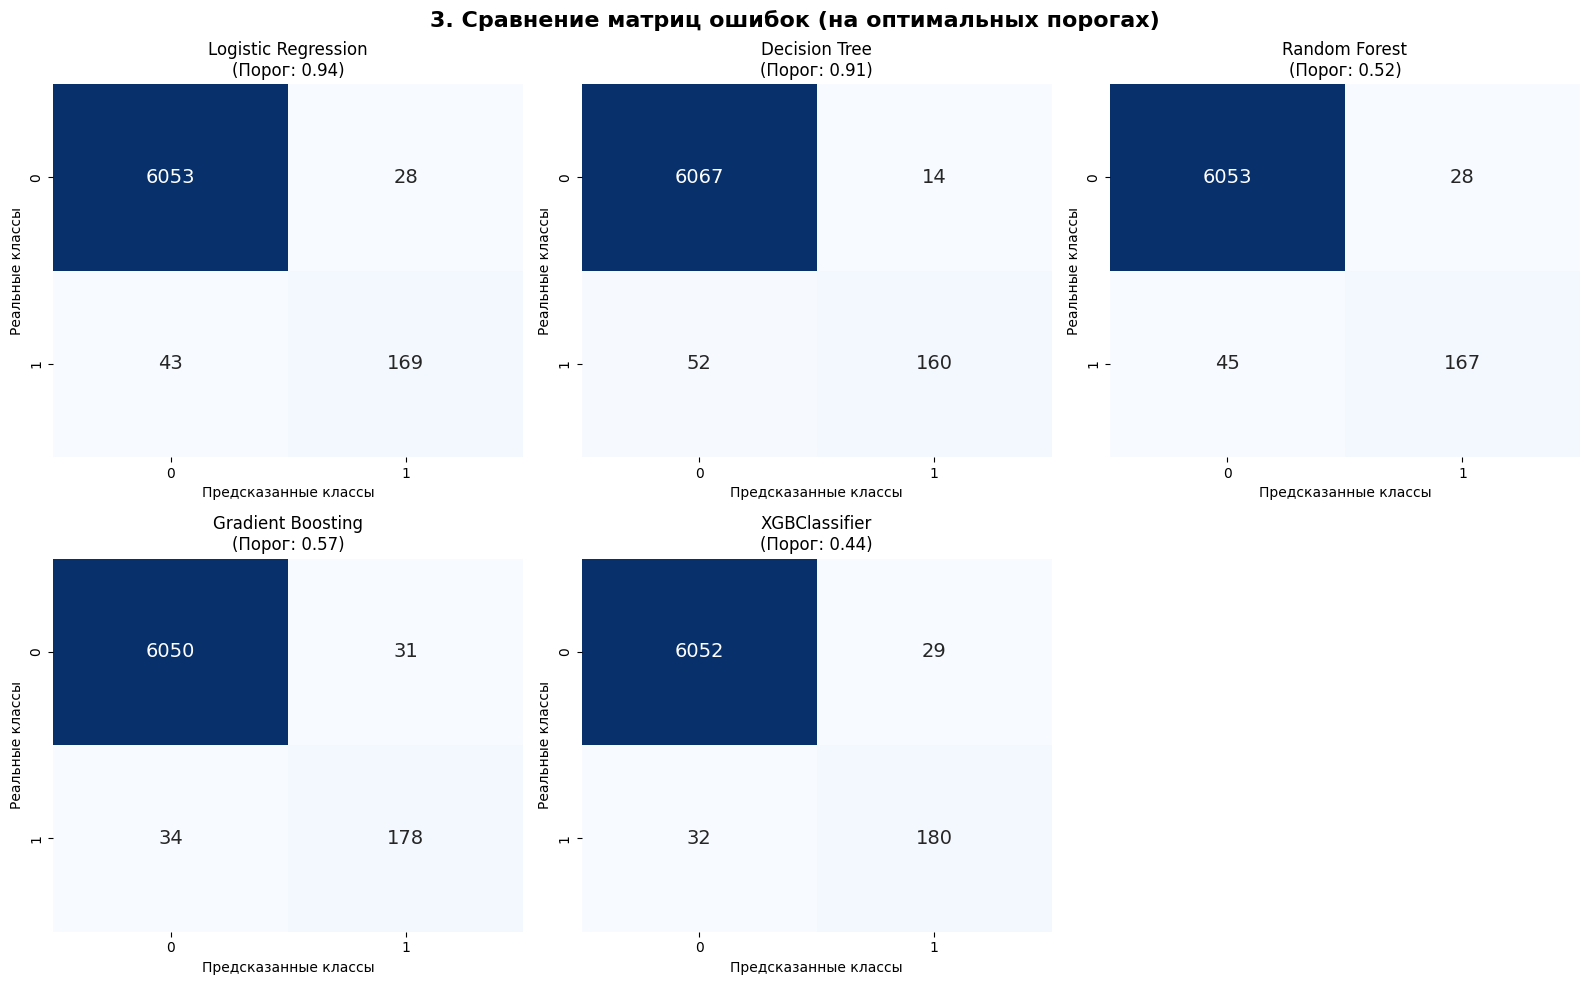


Финальные результаты моделей с оптимизированными порогами:
              Model  Best_Threshold  ROC-AUC  Accuracy  Precision  Precision_w  Recall  Recall_w  F1-Score  F1-Score_w
Logistic Regression          0.9358   0.9887    0.9887     0.8579       0.9884  0.7972    0.9887    0.8264      0.9885
      Decision Tree          0.9075   0.9726    0.9895     0.9195       0.9891  0.7547    0.9895    0.8290      0.9890
      Random Forest          0.5249   0.9860    0.9884     0.8564       0.9880  0.7877    0.9884    0.8206      0.9882
  Gradient Boosting          0.5674   0.9871    0.9897     0.8517       0.9896  0.8396    0.9897    0.8456      0.9896
      XGBClassifier          0.4446   0.9914    0.9903     0.8612       0.9902  0.8491    0.9903    0.8551      0.9903

Лучшая модель по F1-Score (с учетом оптимизации порога): XGBClassifier


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_split=4, min_samples_leaf=2, criterion='entropy', max_features=None, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=109, max_depth=16, min_samples_split=5, min_samples_leaf=1, max_features='log2', bootstrap=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=108, learning_rate=0.03736563332951993, max_depth=8, min_samples_split=13, min_samples_leaf=6, subsample=0.6816427025399264, max_features=None, random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42)
}

results = []
thresholds = np.linspace(0.01, 0.95, 200)

saved_probas = {}
saved_finals = {}
saved_thresholds = {}

for name, model in models.items():
    
    model.fit(X_train_res, y_train_res)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    saved_probas[name] = y_proba
    
    roc_auc = roc_auc_score(y_test, y_proba)
    
    best_t = 0.5
    best_recall = 0
    best_metrics = {}
    
    for t in thresholds:
        y_pred_temp = (y_proba >= t).astype(int)
        rec = recall_score(y_test, y_pred_temp, zero_division=0)
        prec = precision_score(y_test, y_pred_temp, zero_division=0)
        
        if rec > best_recall and prec > 0.85:
            best_recall = rec
            best_t = t
            best_metrics = {
                'Model': name,
                'Best_Threshold': round(t, 4),
                'ROC-AUC': roc_auc,
                'Accuracy': accuracy_score(y_test, y_pred_temp),
                'Precision': prec,
                'Precision_w': precision_score(y_test, y_pred_temp, average='weighted', zero_division=0),
                'Recall': rec,
                'Recall_w': recall_score(y_test, y_pred_temp, average='weighted', zero_division=0),
                'F1-Score': f1_score(y_test, y_pred_temp, zero_division=0),
                'F1-Score_w': f1_score(y_test, y_pred_temp, average='weighted', zero_division=0)
            }
            
    if not best_metrics:
        y_pred_temp = (y_proba >= 0.5).astype(int)
        best_metrics = {
            'Model': name, 'Best_Threshold': 0.5, 'ROC-AUC': roc_auc,
            'Accuracy': accuracy_score(y_test, y_pred_temp), 'Precision': precision_score(y_test, y_pred_temp, zero_division=0),
            'Precision_w': precision_score(y_test, y_pred_temp, average='weighted', zero_division=0), 'Recall': recall_score(y_test, y_pred_temp, zero_division=0),
            'Recall_w': recall_score(y_test, y_pred_temp, average='weighted', zero_division=0), 'F1-Score': f1_score(y_test, y_pred_temp, zero_division=0),
            'F1-Score_w': f1_score(y_test, y_pred_temp, average='weighted', zero_division=0)
        }
        best_t = 0.5

    results.append(best_metrics)
    saved_finals[name] = (y_proba >= best_t).astype(int)
    saved_thresholds[name] = best_t


fig1, axes1 = plt.subplots(2, 3, figsize=(16, 10))
fig1.suptitle("1. Сравнение распределения предсказанных вероятностей класса 1", fontsize=16, fontweight='bold')
axes1 = axes1.flatten()

for i, name in enumerate(models.keys()):
    sns.kdeplot(saved_probas[name], fill=True, ax=axes1[i], color="purple")
    axes1[i].set_title(name, fontsize=12)
    axes1[i].set_xlabel("Вероятность класса")
    axes1[i].set_ylabel("Плотность")
    axes1[i].grid(True)

fig1.delaxes(axes1[5]) 
plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
fig2.suptitle("2. Сравнение ROC-кривых моделей", fontsize=16, fontweight='bold')
axes2 = axes2.flatten()

for i, name in enumerate(models.keys()):
    fpr, tpr, _ = roc_curve(y_test, saved_probas[name])
    auc_val = saved_probas_auc = results[i]['ROC-AUC']
    
    axes2[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.4f}')
    axes2[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes2[i].set_xlim([0.0, 1.0])
    axes2[i].set_ylim([0.0, 1.05])
    axes2[i].set_title(name, fontsize=12)
    axes2[i].set_xlabel("False Positive Rate")
    axes2[i].set_ylabel("True Positive Rate")
    axes2[i].legend(loc="lower right")
    axes2[i].grid(True)

fig2.delaxes(axes2[5])
plt.tight_layout()
plt.show()


fig3, axes3 = plt.subplots(2, 3, figsize=(16, 10))
fig3.suptitle("3. Сравнение матриц ошибок (на оптимальных порогах)", fontsize=16, fontweight='bold')
axes3 = axes3.flatten()

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, saved_finals[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes3[i], annot_kws={"size": 14})
    axes3[i].set_title(f"{name}\n(Порог: {saved_thresholds[name]:.2f})", fontsize=12)
    axes3[i].set_ylabel("Реальные классы")
    axes3[i].set_xlabel("Предсказанные классы")

fig3.delaxes(axes3[5])
plt.tight_layout()
plt.show()
results_df = pd.DataFrame(results)
print("\nФинальные результаты моделей с оптимизированными порогами:")
print(results_df.round(4).to_string(index=False))

best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nЛучшая модель по F1-Score (с учетом оптимизации порога): {best_model}")

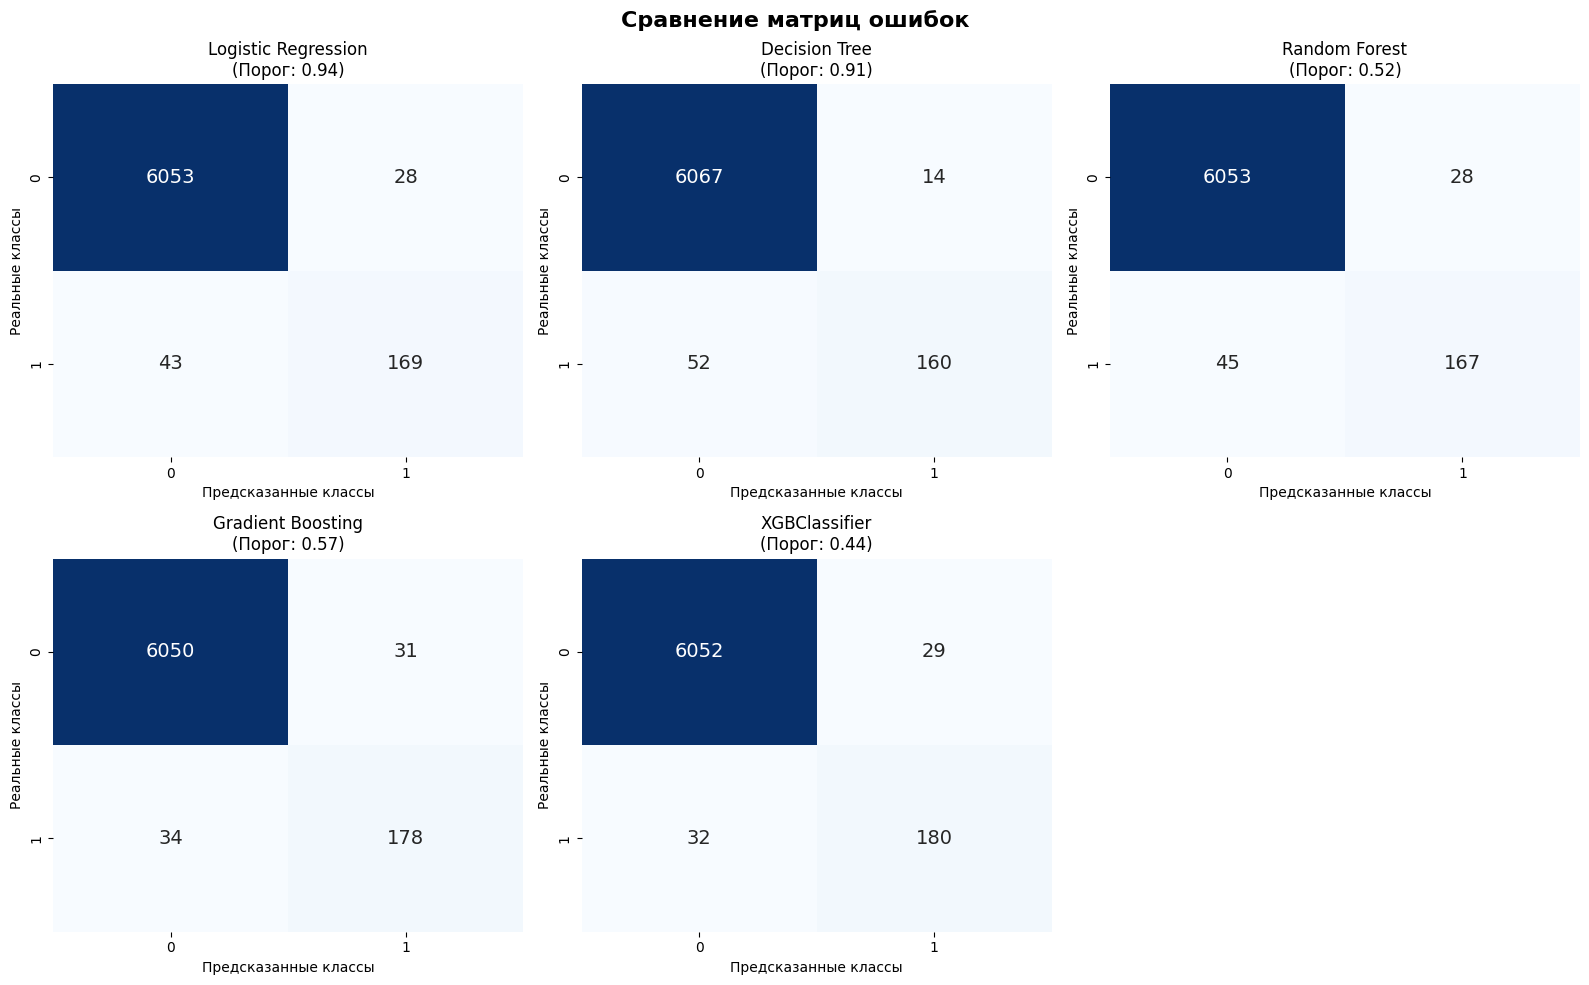

In [34]:
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 10))
fig3.suptitle("Сравнение матриц ошибок", fontsize=16, fontweight='bold')
axes3 = axes3.flatten()

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, saved_finals[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes3[i], annot_kws={"size": 14})
    axes3[i].set_title(f"{name}\n(Порог: {saved_thresholds[name]:.2f})", fontsize=12)
    axes3[i].set_ylabel("Реальные классы")
    axes3[i].set_xlabel("Предсказанные классы")

fig3.delaxes(axes3[5])
plt.tight_layout()
plt.show()

In [36]:
results_df.round(4).to_csv('2.csv', index = False, sep=';')